In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [4]:
df = pd.read_csv("Dataset/fitness_goals.csv")
df.head()

,age,gender,weight,height,bmi,goal,health_condition,activity_level,experience_level,dietary_preference,...,smoking,cigarettes_per_day,alcohol,alcohol_units_per_week,micronutrient_score,protein_intake_g,steps_per_day,water_intake_liters,workout_plan_level,nutrition_plan_level
0,60,male,73.7,1.61,28.43,endurance,hypertension,low,advanced,vegan,...,0,0.0,0,0.0,0.92,182.1,16485,2.49,Medium,NaN
1,17,female,121.0,1.97,31.18,endurance,heart disease,moderate,beginner,veg,...,0,0.0,0,0.0,0.76,167.7,14256,2.04,NaN,NaN
2,43,male,110.0,1.52,47.61,general fitness,none,low,beginner,non-veg,...,0,0.0,0,0.0,0.34,104.9,3050,2.53,Low,Low
3,49,other,73.6,1.96,19.16,general fitness,none,moderate,beginner,non-veg,...,0,0.0,0,0.0,0.71,59.5,2264,3.36,NaN,NaN
4,53,female,80.8,1.76,26.08,endurance,hypertension,high,beginner,pescatarian,...,1,8.7,0,0.0,0.98,51.1,12774,1.90,Medium,NaN


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        10000 non-null  int64  
 1   gender                     10000 non-null  object 
 2   weight                     10000 non-null  float64
 3   height                     10000 non-null  float64
 4   bmi                        10000 non-null  float64
 5   goal                       10000 non-null  object 
 6   health_condition           10000 non-null  object 
 7   activity_level             10000 non-null  object 
 8   experience_level           10000 non-null  object 
 9   dietary_preference         10000 non-null  object 
 10  sleep_hours                10000 non-null  float64
 11  workout_type_preference    10000 non-null  object 
 12  equipment_available_count  10000 non-null  int64  
 13  time_available             10000 non-null  int6

In [63]:
null_counts = df.isnull().sum()

print(f"{null_counts.sum()} null entries have been found in the dataset\n")

df.dropna(inplace=True)

duplicate_count = df.duplicated().sum()

print(f"{duplicate_count} duplicate entries have been found in the dataset\n")

df.drop_duplicates(inplace=True)

print(f"All duplicates have been removed\n")

df.reset_index(drop=True, inplace=True)

print("Categorical columns:",df.select_dtypes(include=['object']).columns.tolist(),'\n')

6535 null entries have been found in the dataset

0 duplicate entries have been found in the dataset

All duplicates have been removed

Categorical columns: ['gender', 'goal', 'health_condition', 'activity_level', 'experience_level', 'dietary_preference', 'workout_type_preference', 'workout_plan_level', 'nutrition_plan_level'] 



In [64]:
df['workout_plan_level'].value_counts()

workout_plan_level
Medium    2435
Low       1809
High       582
Name: count, dtype: int64

In [65]:
df['nutrition_plan_level'].value_counts()

nutrition_plan_level
Medium    2999
Low       1351
High       476
Name: count, dtype: int64

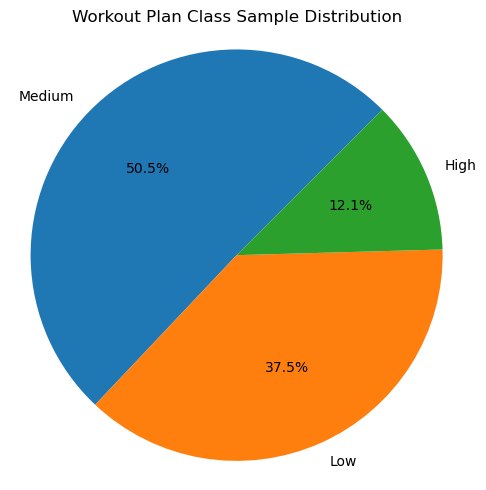

In [66]:
target = df['workout_plan_level'].value_counts()
labels = ['High', 'Low', 'Medium', 'None']
plt.figure(figsize=(5, 5))
plt.pie(
    target.values,
    labels=target.index,
    autopct='%1.1f%%',
    startangle=45
)

plt.title("Workout Plan Class Sample Distribution")
plt.axis('equal')
plt.tight_layout()
plt.show()

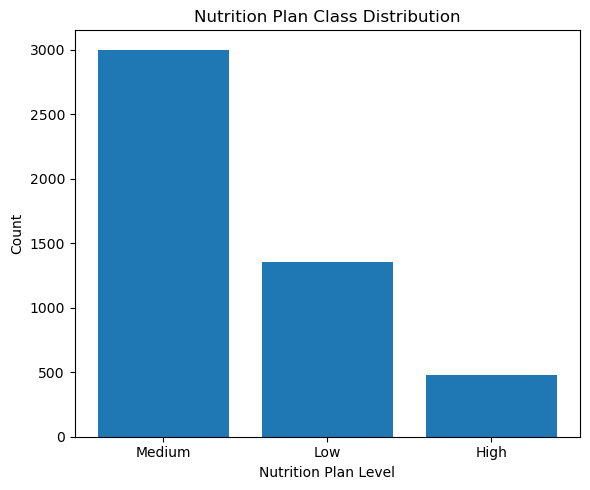

In [67]:
target =  df['nutrition_plan_level'].value_counts()

plt.figure(figsize=(6, 5))
plt.bar(target.index, target.values)

plt.xlabel("Nutrition Plan Level")
plt.ylabel("Count")
plt.title("Nutrition Plan Class Distribution")

plt.tight_layout()
plt.show()

In [68]:
import numpy as np
import pandas as pd

def remove_outliers_iqr(df, threshold=1.5):
    df_clean = df.copy()
    
    numeric_cols = df_clean.select_dtypes(include=np.number).columns
    
    for col in numeric_cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - threshold * IQR
        upper = Q3 + threshold * IQR
        
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    
    return df_clean

# Apply
df_clean = remove_outliers_iqr(df)

In [69]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = df.select_dtypes(include=["object"]).columns
print(categorical_cols)

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    
joblib.dump(label_encoders, "Models/label_encoders.pkl")

Index(['gender', 'goal', 'health_condition', 'activity_level',
       'experience_level', 'dietary_preference', 'workout_type_preference',
       'workout_plan_level', 'nutrition_plan_level'],
      dtype='object')


['Models/label_encoders.pkl']

In [70]:
target1 = "workout_plan_level"
target2 = "nutrition_plan_level"

X = df.drop([target1, target2], axis=1)
y1 = df[target1]
y2 = df[target2]

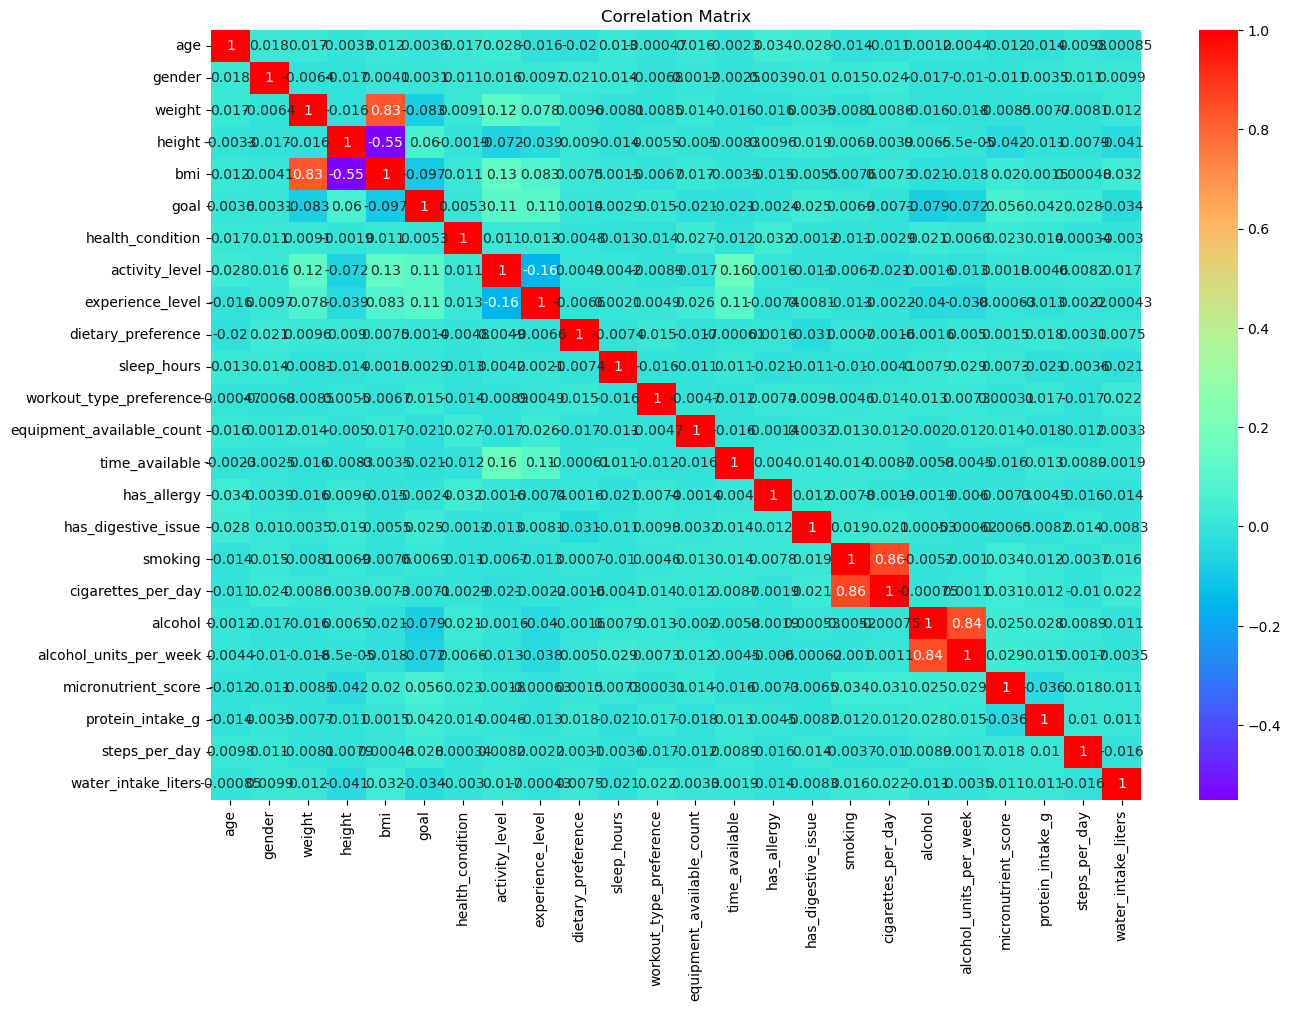

In [71]:
plt.figure(figsize = (15,10))
sns.heatmap(X.corr(), annot = True, cmap="rainbow")
plt.title('Correlation Matrix')
plt.show()

In [72]:
categorical_cols = X.select_dtypes(include="object").columns.tolist()
numeric_cols = X.select_dtypes(exclude="object").columns.tolist()

In [73]:
from sklearn.model_selection import train_test_split

X_train, X_test, y1_train, y1_test, y2_train, y2_test = train_test_split(
    X, y1, y2,
    test_size=0.2,
    random_state=42,
    stratify=y1
)

In [74]:
xai_X_train, xai_X_test, xai_y1_train, xai_y1_test, xai_y2_train, xai_y2_test = X_train, X_test, y1_train, y1_test, y2_train, y2_test

In [75]:
X_train.shape

(3860, 24)

In [76]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

ML_Model = []
Target = []
accuracy = []
precision = []
recall = []
f1score = []


def storeResults(model, target_name, a, b, c, d):
    ML_Model.append(model) 
    Target.append(target_name)
    accuracy.append(round(a, 4)) 
    precision.append(round(b, 4))
    recall.append(round(c, 4))
    f1score.append(round(d, 4))


# RandomForestClassifier

In [77]:
from sklearn.ensemble import RandomForestClassifier

rf1 = RandomForestClassifier(
    n_estimators=100,
    max_depth=7,
    random_state=42,
    n_jobs=-1
)

rf1.fit(X_train, y1_train)

y1_pred = rf1.predict(X_test)

print("Stage 1 - Workout Plan Classification Report")
print(classification_report(y1_test, y1_pred, target_names=labels))

rf_acc_1 = accuracy_score(y1_test, y1_pred)
rf_prec_1 = precision_score(y1_test, y1_pred, average='weighted')
rf_rec_1 = recall_score(y1_test, y1_pred, average='weighted')
rf_f1_1 = f1_score(y1_test, y1_pred, average='weighted')

cm = confusion_matrix(y1_test, y1_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues')

Stage 1 - Workout Plan Classification Report


ValueError: Number of classes, 3, does not match size of target_names, 4. Try specifying the labels parameter

In [ ]:
storeResults("RandomForest", "Workout Plan", rf_acc_1, rf_prec_1, rf_rec_1, rf_f1_1)

Stage 2 - Nutrition Plan Classification Report
              precision    recall  f1-score   support

        High       1.00      0.78      0.88       117
         Low       1.00      0.98      0.99       498
      Medium       0.96      1.00      0.98       898
        None       1.00      1.00      1.00       487

    accuracy                           0.98      2000
   macro avg       0.99      0.94      0.96      2000
weighted avg       0.98      0.98      0.98      2000



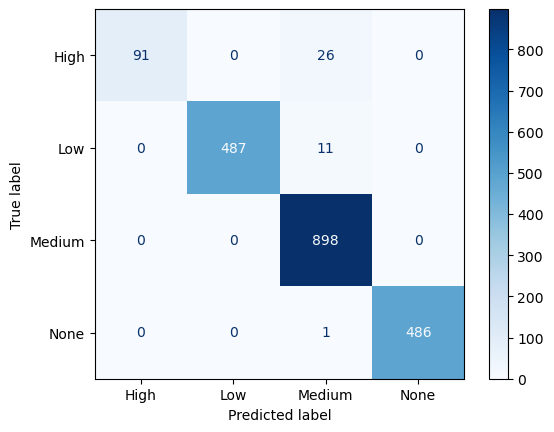

In [ ]:
X_train_stage2 = X_train.copy()
X_test_stage2 = X_test.copy()

# Use TRAIN predictions for training stage2
X_train_stage2["predicted_workout_plan"] = rf1.predict(X_train)

# Use TEST predictions for testing stage2
X_test_stage2["predicted_workout_plan"] = y1_pred

rf2 = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf2.fit(X_train_stage2, y2_train)

y2_pred = rf2.predict(X_test_stage2)

print("Stage 2 - Nutrition Plan Classification Report")
print(classification_report(y2_test, y2_pred, target_names=labels))

rf_acc_2 = accuracy_score(y2_test, y2_pred)
rf_prec_2 = precision_score(y2_test, y2_pred, average='weighted')
rf_rec_2 = recall_score(y2_test, y2_pred, average='weighted')
rf_f1_2 = f1_score(y2_test, y2_pred, average='weighted')

cm = confusion_matrix(y2_test, y2_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues')

In [ ]:
storeResults("RandomForest", "Nutrition Plan", rf_acc_2, rf_prec_2, rf_rec_2, rf_f1_2)

# DecisionTree

Stage 1 - Workout Plan Classification Report
              precision    recall  f1-score   support

        High       1.00      0.62      0.76       134
         Low       0.72      0.70      0.71       474
      Medium       0.90      0.78      0.84       606
        None       0.85      1.00      0.92       786

    accuracy                           0.84      2000
   macro avg       0.87      0.78      0.81      2000
weighted avg       0.84      0.84      0.83      2000



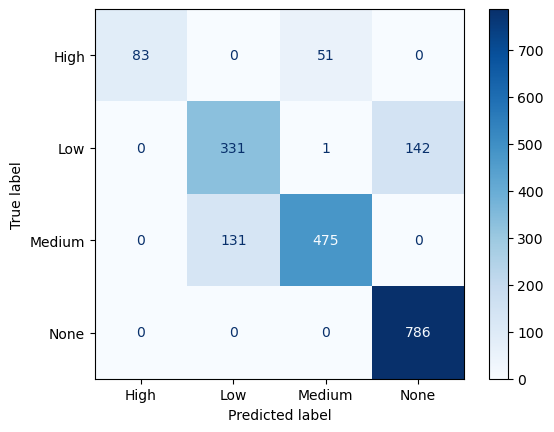

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Stage 1 Model
dt1 = DecisionTreeClassifier(max_depth=4,random_state=42)

dt1.fit(X_train, y1_train)

y1_pred = dt1.predict(X_test)

print("Stage 1 - Workout Plan Classification Report")
print(classification_report(y1_test, y1_pred, target_names=labels))

dt_acc_1 = accuracy_score(y1_test, y1_pred)
dt_prec_1 = precision_score(y1_test, y1_pred, average='weighted')
dt_rec_1 = recall_score(y1_test, y1_pred, average='weighted')
dt_f1_1 = f1_score(y1_test, y1_pred, average='weighted')

cm1 = confusion_matrix(y1_test, y1_pred)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=labels)
disp1.plot(cmap='Blues')

In [ ]:
storeResults("DecisionTree", "Workout Plan", dt_acc_1, dt_prec_1, dt_rec_1, dt_f1_1)

Stage 2 - Nutrition Plan Classification Report
              precision    recall  f1-score   support

        High       1.00      0.79      0.88       117
         Low       0.90      0.93      0.91       498
      Medium       0.97      0.95      0.96       898
        None       0.93      1.00      0.96       487

    accuracy                           0.94      2000
   macro avg       0.95      0.91      0.93      2000
weighted avg       0.95      0.94      0.94      2000



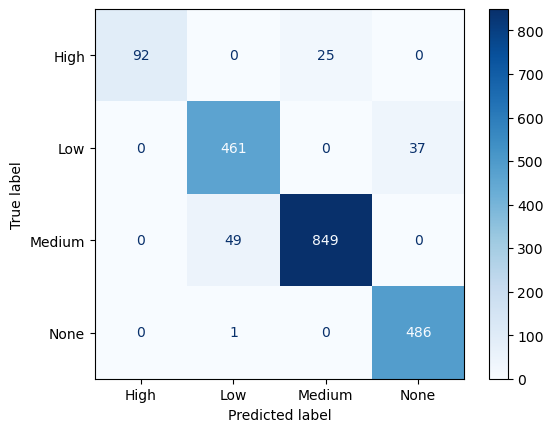

In [ ]:
# Add Stage 1 Predictions

X_train_stage2 = X_train.copy()
X_test_stage2 = X_test.copy()

X_train_stage2["predicted_workout_plan"] = dt1.predict(X_train)

X_test_stage2["predicted_workout_plan"] = y1_pred

dt2 = DecisionTreeClassifier(max_depth=6,random_state=42)

dt2.fit(X_train_stage2, y2_train)

y2_pred = dt2.predict(X_test_stage2)

print("Stage 2 - Nutrition Plan Classification Report")
print(classification_report(y2_test, y2_pred, target_names=labels))

dt_acc_2 = accuracy_score(y2_test, y2_pred)
dt_prec_2 = precision_score(y2_test, y2_pred, average='weighted')
dt_rec_2 = recall_score(y2_test, y2_pred, average='weighted')
dt_f1_2 = f1_score(y2_test, y2_pred, average='weighted')

cm2 = confusion_matrix(y2_test, y2_pred)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=labels)
disp2.plot(cmap='Blues')

In [ ]:
storeResults("DecisionTree", "Nutrition Plan", dt_acc_2, dt_prec_2, dt_rec_2, dt_f1_2)

# Catboost

Stage 1 - Workout Plan Classification Report
              precision    recall  f1-score   support

        High       0.99      0.87      0.93       134
         Low       0.88      0.99      0.93       474
      Medium       0.97      0.89      0.93       606
        None       1.00      1.00      1.00       786

    accuracy                           0.96      2000
   macro avg       0.96      0.94      0.95      2000
weighted avg       0.96      0.96      0.96      2000



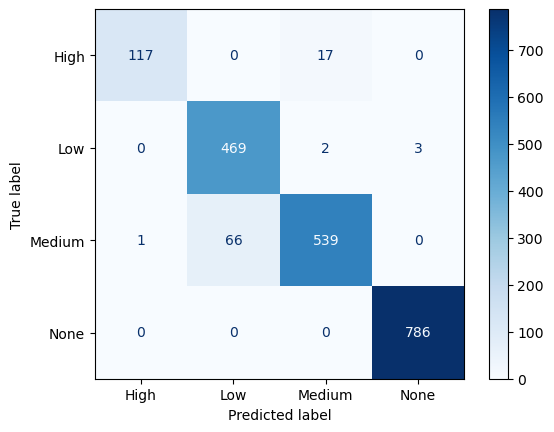

In [ ]:
from catboost import CatBoostClassifier

cat1 = CatBoostClassifier(
    iterations=100,
    depth=4,               
    learning_rate=0.01,
    loss_function='MultiClass',
    random_state=42,
    verbose=0
)

cat1.fit(X_train, y1_train)

y1_pred = cat1.predict(X_test)

print("Stage 1 - Workout Plan Classification Report")
print(classification_report(y1_test, y1_pred, target_names=labels))

# Metrics
cat_acc_1 = accuracy_score(y1_test, y1_pred)
cat_prec_1 = precision_score(y1_test, y1_pred, average='weighted')
cat_rec_1 = recall_score(y1_test, y1_pred, average='weighted')
cat_f1_1 = f1_score(y1_test, y1_pred, average='weighted')

# Confusion Matrix
cm1 = confusion_matrix(y1_test, y1_pred)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=labels)
disp1.plot(cmap='Blues')

In [ ]:
storeResults("Catboost", "Workout Plan", cat_acc_1, cat_prec_1, cat_rec_1, cat_f1_1)

Stage 2 - Nutrition Plan Classification Report
              precision    recall  f1-score   support

        High       1.00      0.51      0.68       117
         Low       0.94      0.94      0.94       498
      Medium       0.94      0.97      0.95       898
        None       0.95      1.00      0.97       487

    accuracy                           0.94      2000
   macro avg       0.95      0.85      0.88      2000
weighted avg       0.94      0.94      0.94      2000



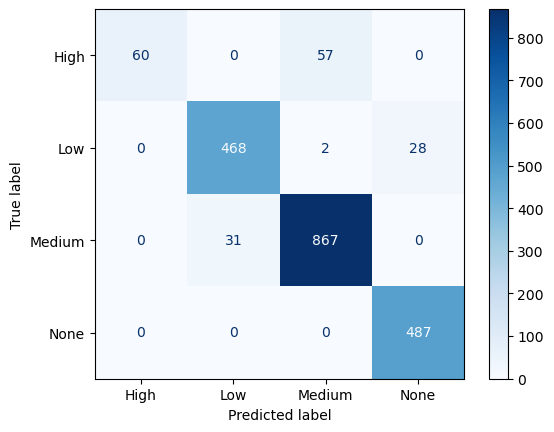

In [ ]:
X_train_stage2 = X_train.copy()
X_test_stage2 = X_test.copy()

X_train_stage2["predicted_workout_plan"] = cat1.predict(X_train)
X_test_stage2["predicted_workout_plan"] = y1_pred

cat2 = CatBoostClassifier(
    iterations=250,
    depth=4,                 # very shallow trees
    learning_rate=0.01,
    loss_function='MultiClass',
    random_state=42,
    verbose=0
)

cat2.fit(X_train_stage2, y2_train)

y2_pred = cat2.predict(X_test_stage2)

print("Stage 2 - Nutrition Plan Classification Report")
print(classification_report(y2_test, y2_pred, target_names=labels))

# Metrics
cat_acc_2 = accuracy_score(y2_test, y2_pred)
cat_prec_2 = precision_score(y2_test, y2_pred, average='weighted')
cat_rec_2 = recall_score(y2_test, y2_pred, average='weighted')
cat_f1_2 = f1_score(y2_test, y2_pred, average='weighted')

# Confusion Matrix
cm2 = confusion_matrix(y2_test, y2_pred)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=labels)
disp2.plot(cmap='Blues')

In [ ]:
storeResults("Catboost", "Nutrition Plan", cat_acc_2, cat_prec_2, cat_rec_2, cat_f1_2)

# XGBoost

Stage 1 - Workout Plan Classification Report
              precision    recall  f1-score   support

        High       1.00      0.73      0.84       134
         Low       0.98      1.00      0.99       474
      Medium       0.94      0.99      0.96       606
        None       1.00      1.00      1.00       786

    accuracy                           0.98      2000
   macro avg       0.98      0.93      0.95      2000
weighted avg       0.98      0.98      0.98      2000



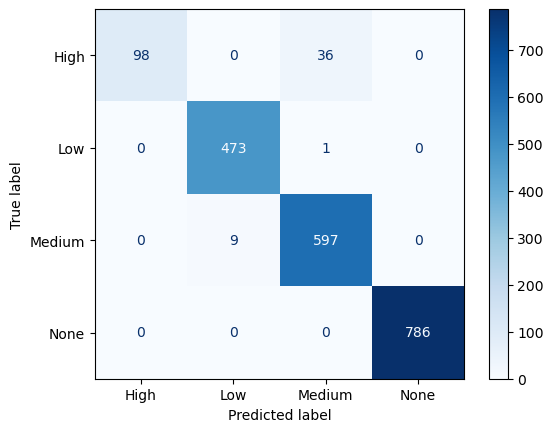

In [ ]:
from xgboost import XGBClassifier

xgb1 = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.01,
#     subsample=0.8,
    colsample_bytree=0.6,

    random_state=42,
    eval_metric='mlogloss'
)
xgb1.fit(X_train, y1_train)

y1_pred = xgb1.predict(X_test)

print("Stage 1 - Workout Plan Classification Report")
print(classification_report(y1_test, y1_pred, target_names=labels))

# Metrics
xgb_acc_1 = accuracy_score(y1_test, y1_pred)
xgb_prec_1 = precision_score(y1_test, y1_pred, average='weighted')
xgb_rec_1 = recall_score(y1_test, y1_pred, average='weighted')
xgb_f1_1 = f1_score(y1_test, y1_pred, average='weighted')

# Confusion Matrix
cm1 = confusion_matrix(y1_test, y1_pred)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=labels)
disp1.plot(cmap='Blues')

In [ ]:
storeResults("XGBoost", "Workout Plan", xgb_acc_1, xgb_prec_1, xgb_rec_1, xgb_f1_1)

Stage 2 - Nutrition Plan Classification Report
              precision    recall  f1-score   support

        High       1.00      0.60      0.75       117
         Low       0.99      0.93      0.96       498
      Medium       0.94      0.99      0.97       898
        None       0.95      1.00      0.98       487

    accuracy                           0.96      2000
   macro avg       0.97      0.88      0.91      2000
weighted avg       0.96      0.96      0.95      2000



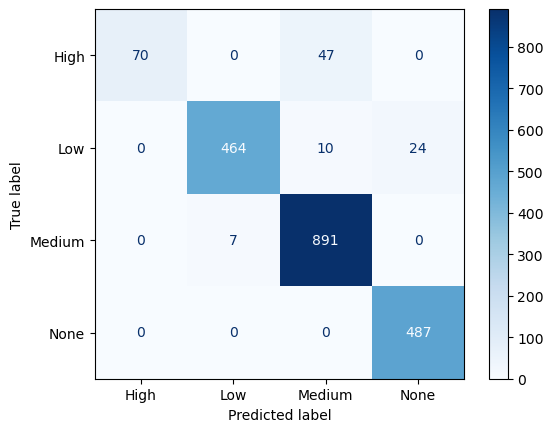

In [ ]:
# Add Stage 1 predictions
X_train_stage2 = X_train.copy()
X_test_stage2 = X_test.copy()

X_train_stage2["predicted_workout_plan"] = xgb1.predict(X_train)
X_test_stage2["predicted_workout_plan"] = y1_pred

xgb2 = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.01,
#     subsample=0.8,
    colsample_bytree=0.6,

    random_state=42,
    eval_metric='mlogloss'
)

xgb2.fit(X_train_stage2, y2_train)

y2_pred = xgb2.predict(X_test_stage2)

print("Stage 2 - Nutrition Plan Classification Report")
print(classification_report(y2_test, y2_pred, target_names=labels))

# Metrics
xgb_acc_2 = accuracy_score(y2_test, y2_pred)
xgb_prec_2 = precision_score(y2_test, y2_pred, average='weighted')
xgb_rec_2 = recall_score(y2_test, y2_pred, average='weighted')
xgb_f1_2 = f1_score(y2_test, y2_pred, average='weighted')

# Confusion Matrix
cm2 = confusion_matrix(y2_test, y2_pred)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=labels)
disp2.plot(cmap='Blues')

In [ ]:
storeResults("XGBoost", "Nutrition Plan", xgb_acc_2, xgb_prec_2, xgb_rec_2, xgb_f1_2)

# KNN

Stage 1 - Workout Plan Classification Report
              precision    recall  f1-score   support

        High       0.20      0.01      0.01       134
         Low       0.25      0.14      0.18       474
      Medium       0.31      0.28      0.30       606
        None       0.44      0.66      0.53       786

    accuracy                           0.38      2000
   macro avg       0.30      0.27      0.25      2000
weighted avg       0.34      0.38      0.34      2000



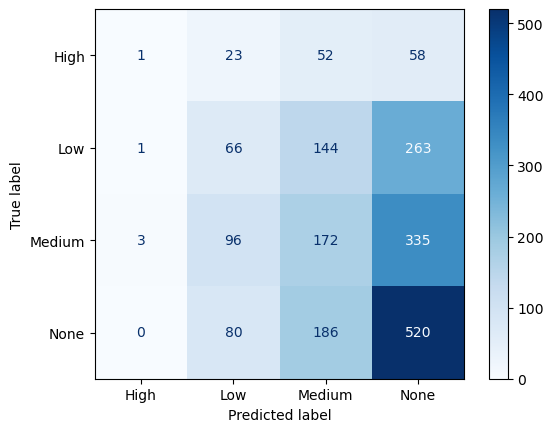

In [ ]:
from sklearn.neighbors import KNeighborsClassifier


knn1 = KNeighborsClassifier(
    n_neighbors=20
)

knn1.fit(X_train, y1_train)

y1_pred = knn1.predict(X_test)

print("Stage 1 - Workout Plan Classification Report")
print(classification_report(y1_test, y1_pred, target_names=labels))

# Metrics
knn_acc_1 = accuracy_score(y1_test, y1_pred)
knn_prec_1 = precision_score(y1_test, y1_pred, average='weighted')
knn_rec_1 = recall_score(y1_test, y1_pred, average='weighted')
knn_f1_1 = f1_score(y1_test, y1_pred, average='weighted')

# Confusion Matrix
cm1 = confusion_matrix(y1_test, y1_pred)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=labels)
disp1.plot(cmap='Blues')

In [ ]:
storeResults("KNN", "Workout Plan", knn_acc_1, knn_prec_1, knn_rec_1, knn_f1_1)

Stage 2 - Nutrition Plan Classification Report
              precision    recall  f1-score   support

        High       0.00      0.00      0.00       117
         Low       0.33      0.11      0.16       498
      Medium       0.48      0.80      0.60       898
        None       0.34      0.24      0.28       487

    accuracy                           0.44      2000
   macro avg       0.29      0.29      0.26      2000
weighted avg       0.38      0.44      0.38      2000



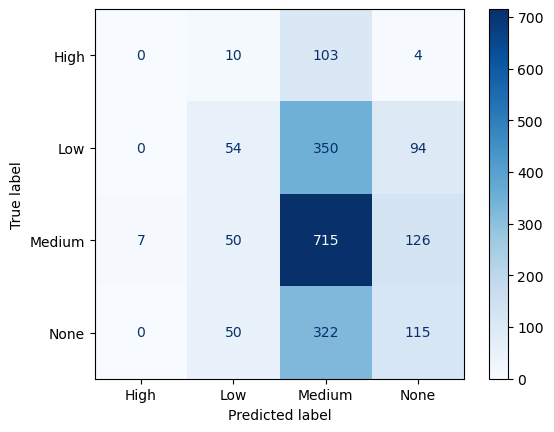

In [ ]:
# Add Stage 1 predictions
X_train_stage2 = X_train.copy()
X_test_stage2 = X_test.copy()

X_train_stage2["predicted_workout_plan"] = knn1.predict(X_train)
X_test_stage2["predicted_workout_plan"] = y1_pred


knn2 = KNeighborsClassifier(
    n_neighbors=20,
    weights='distance',
    metric='minkowski',
    p=2
)

knn2.fit(X_train_stage2, y2_train)

y2_pred = knn2.predict(X_test_stage2)

print("Stage 2 - Nutrition Plan Classification Report")
print(classification_report(y2_test, y2_pred, target_names=labels))

# Metrics
knn_acc_2 = accuracy_score(y2_test, y2_pred)
knn_prec_2 = precision_score(y2_test, y2_pred, average='weighted')
knn_rec_2 = recall_score(y2_test, y2_pred, average='weighted')
knn_f1_2 = f1_score(y2_test, y2_pred, average='weighted')

# Confusion Matrix
cm2 = confusion_matrix(y2_test, y2_pred)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=labels)
disp2.plot(cmap='Blues')

In [ ]:
storeResults("KNN", "Nutrition Plan", knn_acc_2, knn_prec_2, knn_rec_2, knn_f1_2)

# Voting classifier

Stage 1 - Workout Plan Classification Report
              precision    recall  f1-score   support

        High       0.99      0.94      0.97       134
         Low       1.00      1.00      1.00       474
      Medium       0.99      1.00      0.99       606
        None       1.00      1.00      1.00       786

    accuracy                           0.99      2000
   macro avg       0.99      0.98      0.99      2000
weighted avg       0.99      0.99      0.99      2000



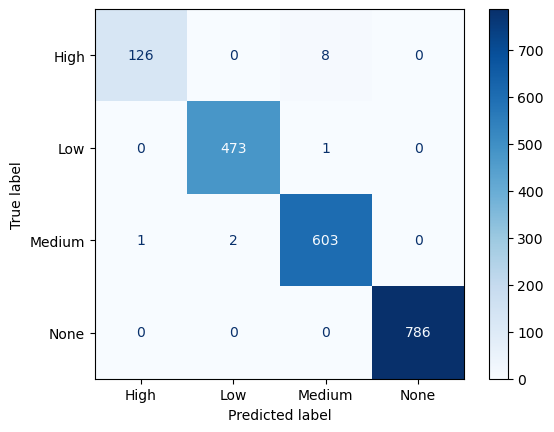

In [ ]:
from sklearn.ensemble import VotingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

rf1 = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

gb1 = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.01,
    max_depth=3,
    random_state=42
)

xgb1 = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=4,
    eval_metric='mlogloss',
    random_state=42
)

vote1 = VotingClassifier(
    estimators=[
        ('rf', rf1),
        ('gb', gb1),
        ('xgb', xgb1)
    ],
    voting='soft',
    n_jobs=-1
)

vote1.fit(X_train, y1_train)

y1_pred = vote1.predict(X_test)

print("Stage 1 - Workout Plan Classification Report")
print(classification_report(y1_test, y1_pred, target_names=labels))

# Metrics
vote_acc_1 = accuracy_score(y1_test, y1_pred)
vote_prec_1 = precision_score(y1_test, y1_pred, average='weighted')
vote_rec_1 = recall_score(y1_test, y1_pred, average='weighted')
vote_f1_1 = f1_score(y1_test, y1_pred, average='weighted')

# Confusion Matrix
cm1 = confusion_matrix(y1_test, y1_pred)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=labels)
disp1.plot(cmap='Blues')

In [ ]:
joblib.dump(vote1, "Models/Voting_Workout_model.sav")

['Models/Voting_Workout_model.sav']

In [ ]:
storeResults("Voting Classifier", "Workout Plan", vote_acc_1, vote_prec_1, vote_rec_1, vote_f1_1)

Stage 2 - Nutrition Plan Classification Report
              precision    recall  f1-score   support

        High       1.00      0.92      0.96       117
         Low       0.99      0.98      0.98       498
      Medium       0.98      1.00      0.99       898
        None       0.99      1.00      0.99       487

    accuracy                           0.99      2000
   macro avg       0.99      0.97      0.98      2000
weighted avg       0.99      0.99      0.99      2000



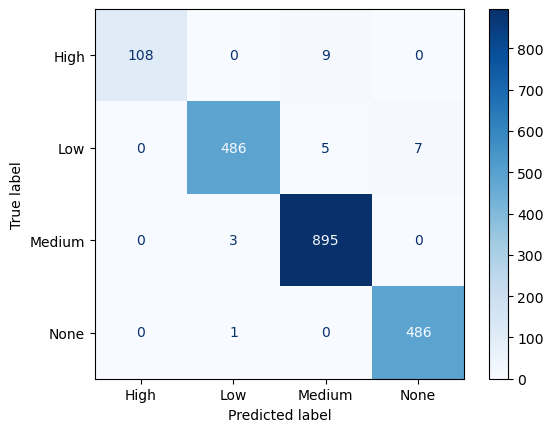

In [ ]:
# Add Stage 1 Predictions
X_train_stage2 = X_train.copy()
X_test_stage2 = X_test.copy()

X_train_stage2["predicted_workout_plan"] = vote1.predict(X_train)
X_test_stage2["predicted_workout_plan"] = y1_pred

rf2 = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

gb2 = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.01,
    max_depth=5,
    random_state=42
)

xgb2 = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=4,
    eval_metric='mlogloss',
    random_state=42
)

vote2 = VotingClassifier(
    estimators=[
        ('rf', rf2),
        ('gb', gb2),
        ('xgb', xgb2)
    ],
    voting='soft',
    n_jobs=-1
)

vote2.fit(X_train_stage2, y2_train)

y2_pred = vote2.predict(X_test_stage2)

print("Stage 2 - Nutrition Plan Classification Report")
print(classification_report(y2_test, y2_pred, target_names=labels))

# Metrics
vote_acc_2 = accuracy_score(y2_test, y2_pred)
vote_prec_2 = precision_score(y2_test, y2_pred, average='weighted')
vote_rec_2 = recall_score(y2_test, y2_pred, average='weighted')
vote_f1_2 = f1_score(y2_test, y2_pred, average='weighted')

# Confusion Matrix
cm2 = confusion_matrix(y2_test, y2_pred)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=labels)
disp2.plot(cmap='Blues')

In [ ]:
joblib.dump(vote2, "Models/Voting_Nutrition_model.sav")

['Models/Voting_Nutrition_model.sav']

In [ ]:
storeResults("Voting Classifier", "Nutrition Plan", vote_acc_2, vote_prec_2, vote_rec_2, vote_f1_2)

In [ ]:
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Target'   : Target,
                        'Accuracy' : accuracy,
                        'Precision': precision,
                        'Recall'   : recall,
                        'F1-Score': f1score,
                        
                      })

In [ ]:
result

,ML Model,Target,Accuracy,Precision,Recall,F1-Score
0,RandomForest,Workout Plan,0.9685,0.9700,0.9685,0.9666
1,RandomForest,Nutrition Plan,0.9810,0.9818,0.9810,0.9804
2,DecisionTree,Workout Plan,0.8375,0.8428,0.8375,0.8334
3,DecisionTree,Nutrition Plan,0.9440,0.9456,0.9440,0.9436
4,Catboost,Workout Plan,0.9555,0.9584,0.9555,0.9554
5,Catboost,Nutrition Plan,0.9410,0.9427,0.9410,0.9370
6,XGBoost,Workout Plan,0.9770,0.9779,0.9770,0.9759
7,XGBoost,Nutrition Plan,0.9560,0.9579,0.9560,0.9533
8,KNN,Workout Plan,0.3795,0.3403,0.3795,0.3415
9,KNN,Nutrition Plan,0.4420,0.3801,0.4420,0.3773


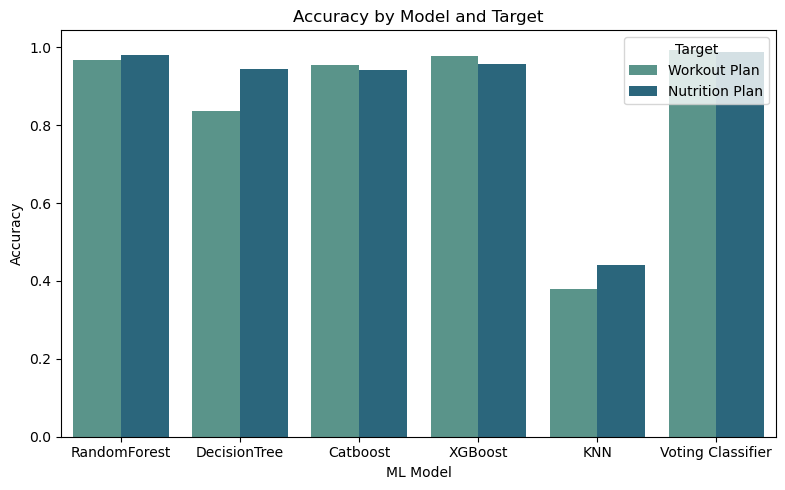

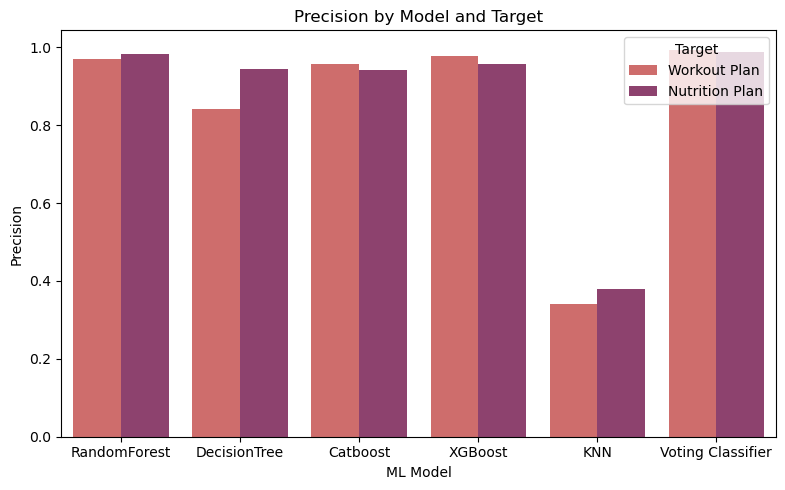

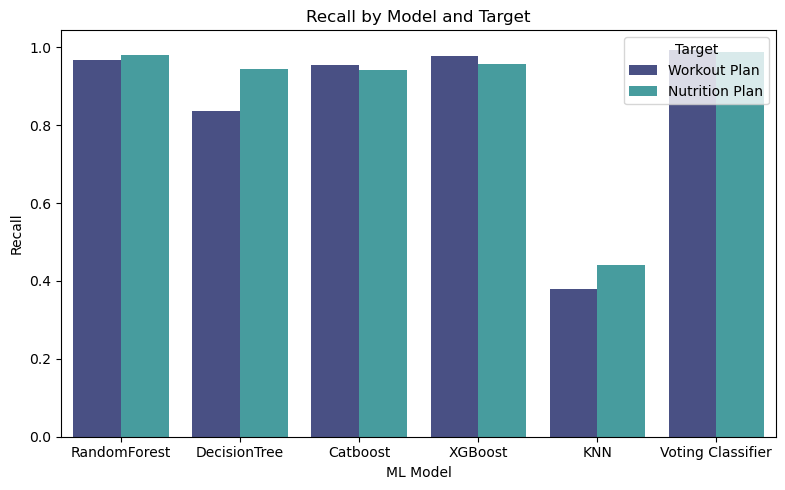

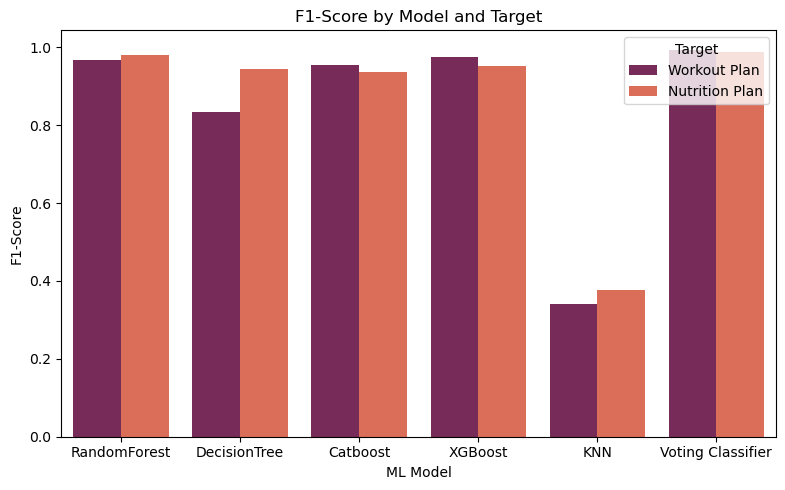

In [ ]:
palettes = {
    'Accuracy': 'crest',
    'Precision': 'flare', 
    'Recall': 'mako', 
    'F1-Score': 'rocket',

}

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for metric in metrics:
    plt.figure(figsize=(8, 5))
    sns.barplot(data=result, x='ML Model', y=metric, hue='Target',  palette=palettes[metric])
    plt.title(f'{metric} by Model and Target')
    plt.xticks(rotation=0)
    plt.legend(title='Target', loc='best')
    plt.tight_layout()
    plt.show()

# XAI

In [ ]:
import joblib

model = joblib.load("Models/Voting_Workout_model.sav")

# XAI - LIME

In [ ]:
from lime import lime_tabular
import plotly.graph_objects as go

feature_names = X.columns.tolist()

X_train_np = X_train if isinstance(X_train, np.ndarray) else X_train.to_numpy()
X_test_np = X_test if isinstance(X_test, np.ndarray) else X_test.to_numpy()

lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train_np,
    feature_names=feature_names,
    class_names=labels,
    mode='classification'
)

i = 5 
explanation = lime_explainer.explain_instance(
    data_row=X_test_np[i],
    predict_fn=model.predict_proba,
    top_labels=1,
    num_features=10
)

explanation.show_in_notebook()

In [ ]:
import plotly.graph_objects as go

label_idx = explanation.available_labels()[0]
exp_list = explanation.as_list(label=label_idx)
features, weights = zip(*exp_list)

fig = go.Figure(go.Waterfall(
    name="LIME Explanation",
    orientation="v",
    measure=["relative"] * len(weights),
    x=features,
    text=[f"{w:.2f}" for w in weights],
    y=weights,
))

fig.update_layout(title=f"LIME Waterfall Explanation (Label: {label_idx})")
fig.show()

# XAI-SHAP

  0%|          | 0/100 [00:00<?, ?it/s]

SHAP shape: (100, 24)


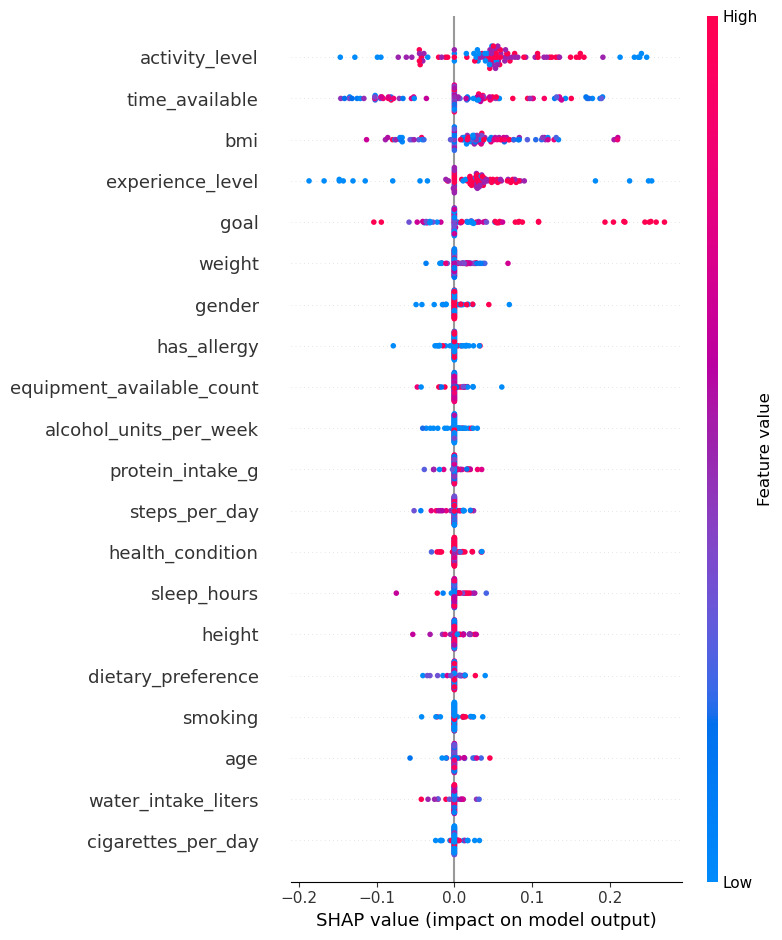

In [ ]:
import shap

X_train_df = pd.DataFrame(X_train_np)

X_background = X_train_df.sample(10, random_state=42)
X_explain = X_train_df.sample(100, random_state=1)

explainer = shap.KernelExplainer(model.predict_proba, X_background)
shap_values = explainer.shap_values(X_explain, nsamples=100)

shap_class_1 = shap_values[:, :, 1]

print("SHAP shape:", shap_class_1.shape)
shap.summary_plot(shap_class_1, X_explain, feature_names=feature_names)